# 注意力机制深入详解

## 注意力机制：深度学习最重要的思想之一

注意力机制的核心直觉：**不是平均对待所有信息，而是根据当前需求，动态地关注更重要的部分。**

类比：
- 你在看一张照片时，不是均匀地看每个像素，而是把注意力集中在关键物体上
- 在读一篇文章时，不同的问题让你关注不同的段落

## 本课内容

1. 注意力的直觉与通用框架
2. 加性注意力 (Bahdanau)
3. 点积注意力 (Luong)
4. 缩放点积注意力 (Transformer)
5. 自注意力 vs 交叉注意力
6. 多头注意力
7. 注意力变体与应用

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math

## 1. 注意力的通用框架

所有注意力机制都遵循同一个框架：

```
输入: Query (查询), Key (键), Value (值)

步骤:
  1. 计算相似度: score = similarity(Query, Key)
  2. 归一化:     weights = softmax(score)
  3. 加权求和:   output = weights @ Value
```

### 三种角色的直觉

| 角色 | 类比 | 作用 |
|------|------|------|
| Query | 搜索词 | "我想找什么" |
| Key | 标签/标题 | "每个条目有什么特征" |
| Value | 内容 | "每个条目的实际内容" |

### 信息检索类比

你在视频网站搜索:
- Query = 你输入的搜索词
- Key = 每个视频的标题和标签
- Value = 视频的实际内容
- 注意力 = 搜索词和标题的匹配度 → 决定你看哪个视频

In [3]:
# 用一个简单例子理解注意力
print("=== 注意力机制简单示例 ===")
print()

# 假设有5个信息源, 每个有3维特征
keys = torch.tensor([
    [1.0, 0.0, 0.0],  # 信息1: 偏向维度1
    [0.0, 1.0, 0.0],  # 信息2: 偏向维度2
    [0.0, 0.0, 1.0],  # 信息3: 偏向维度3
    [0.8, 0.2, 0.0],  # 信息4: 主要维度1, 少量维度2
    [0.0, 0.5, 0.5],  # 信息5: 维度2和3各半
])

values = torch.tensor([
    [10.0],  # 信息1的值
    [20.0],  # 信息2的值
    [30.0],  # 信息3的值
    [15.0],  # 信息4的值
    [25.0],  # 信息5的值
])

# 不同的查询, 得到不同的注意力
queries = {
    '关注维度1': torch.tensor([1.0, 0.0, 0.0]),
    '关注维度2': torch.tensor([0.0, 1.0, 0.0]),
    '关注维度3': torch.tensor([0.0, 0.0, 1.0]),
    '均匀关注':  torch.tensor([0.5, 0.5, 0.5]),
}

for name, query in queries.items():
    scores = query @ keys.T
    weights = torch.softmax(scores, dim=0)
    output = weights @ values
    print(f"{name}:")
    print(f"  注意力权重: {weights.numpy().round(3)}")
    print(f"  加权输出: {output.item():.2f}")
    print()

=== 注意力机制简单示例 ===

关注维度1:
  注意力权重: [0.342 0.126 0.126 0.28  0.126]
  加权输出: 17.07

关注维度2:
  注意力权重: [0.132 0.358 0.132 0.161 0.217]
  加权输出: 20.28

关注维度3:
  注意力权重: [0.136 0.136 0.369 0.136 0.224]
  加权输出: 22.77

均匀关注:
  注意力权重: [0.2 0.2 0.2 0.2 0.2]
  加权输出: 20.00



C:\Users\Administrator\AppData\Local\Temp\ipykernel_14728\2327785681.py:14: UserWarning: Glyph 20851 (\N{CJK UNIFIED IDEOGRAPH-5173}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_14728\2327785681.py:14: UserWarning: Glyph 27880 (\N{CJK UNIFIED IDEOGRAPH-6CE8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_14728\2327785681.py:14: UserWarning: Glyph 32500 (\N{CJK UNIFIED IDEOGRAPH-7EF4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_14728\2327785681.py:14: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_14728\2327785681.py:14: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_147

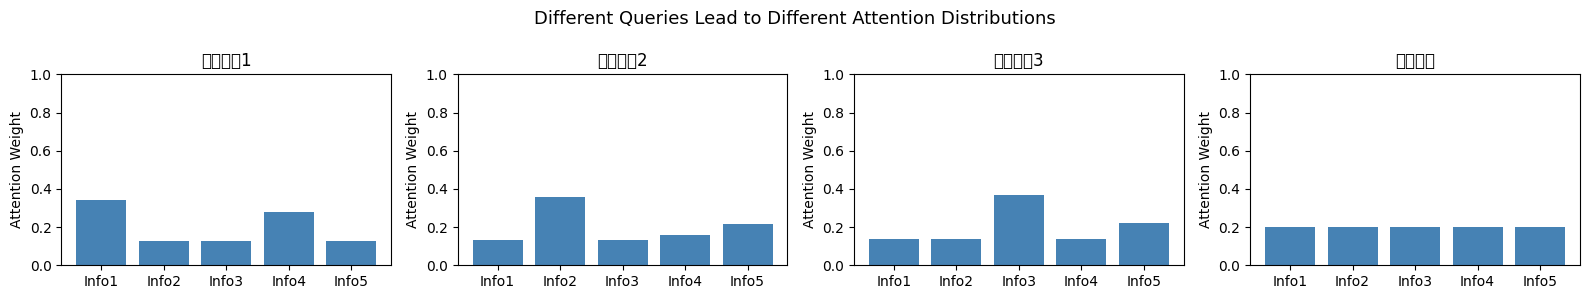

不同的查询关注不同的信息源, 这就是注意力的核心思想


In [4]:
# 可视化不同查询的注意力分布
fig, axes = plt.subplots(1, 4, figsize=(16, 3))
info_labels = ['Info1', 'Info2', 'Info3', 'Info4', 'Info5']

for ax, (name, query) in zip(axes, queries.items()):
    scores = query @ keys.T
    weights = torch.softmax(scores, dim=0)
    ax.bar(info_labels, weights.detach().numpy(), color='steelblue')
    ax.set_title(name)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Attention Weight')

plt.suptitle('Different Queries Lead to Different Attention Distributions', fontsize=13)
plt.tight_layout()
plt.show()

print("不同的查询关注不同的信息源, 这就是注意力的核心思想")

---
## 2. 加性注意力 (Bahdanau Attention, 2014)

最早的注意力机制, 用于 Seq2Seq 翻译模型。

### 计算方式

```
score(h_t, h_s) = v^T * tanh(W1 * h_t + W2 * h_s)
```

- h_t: 解码器隐藏状态 (Query)
- h_s: 编码器隐藏状态 (Key & Value)
- W1, W2, v: 可学习参数

特点: 通过可学习的参数计算相似度, 灵活但参数多。

In [ ]:
class AdditiveAttention(nn.Module):
    def __init__(self, query_dim, key_dim, hidden_dim):
        super().__init__()
        self.W1 = nn.Linear(query_dim, hidden_dim, bias=False)
        self.W2 = nn.Linear(key_dim, hidden_dim, bias=False)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, query, keys, values):
        # query: (B, Q_dim), keys: (B, S, K_dim), values: (B, S, V_dim)
        score = self.v(torch.tanh(self.W1(query.unsqueeze(1)) + self.W2(keys)))
        attn_weights = torch.softmax(score, dim=1)  # (B, S, 1)
        context = (attn_weights * values).sum(dim=1)  # (B, V_dim)
        return context, attn_weights.squeeze(-1)

add_attn = AdditiveAttention(query_dim=32, key_dim=64, hidden_dim=16)
query = torch.randn(2, 32)
keys = torch.randn(2, 10, 64)
values = torch.randn(2, 10, 64)
context, weights = add_attn(query, keys, values)

print(f"Query: {query.shape}")
print(f"Keys:  {keys.shape}")
print(f"Values: {values.shape}")
print(f"Context: {context.shape}")
print(f"Weights: {weights.shape}")
print(f"参数量: {sum(p.numel() for p in add_attn.parameters()):,}")

---
## 3. 点积注意力 (Luong Attention, 2015)

更简单的方式: 直接用 Query 和 Key 的点积作为相似度。

```
score(h_t, h_s) = h_t^T * h_s
```

特点: 无需额外参数, 计算高效, 但要求 Query 和 Key 维度相同。

In [ ]:
class DotProductAttention(nn.Module):
    def forward(self, query, keys, values):
        # query: (B, D), keys: (B, S, D), values: (B, S, V_dim)
        scores = query.unsqueeze(1) @ keys.transpose(1, 2)  # (B, 1, S)
        attn_weights = torch.softmax(scores, dim=-1)  # (B, 1, S)
        context = (attn_weights @ values).squeeze(1)  # (B, V_dim)
        return context, attn_weights.squeeze(1)

dot_attn = DotProductAttention()
query = torch.randn(2, 64)
keys = torch.randn(2, 10, 64)
values = torch.randn(2, 10, 32)
context, weights = dot_attn(query, keys, values)

print(f"点积注意力 (无额外参数!)")
print(f"Query: {query.shape}, Keys: {keys.shape}")
print(f"Context: {context.shape}, Weights: {weights.shape}")
print(f"参数量: {sum(p.numel() for p in dot_attn.parameters()):,}")

---
## 4. 缩放点积注意力 (Scaled Dot-Product Attention)

Transformer 使用的注意力。在点积基础上除以 sqrt(d_k)。

```
Attention(Q, K, V) = softmax(Q @ K^T / sqrt(d_k)) @ V
```

### 为什么需要缩放?

当 d_k 很大时, 点积的方差也很大 → softmax 输出接近 one-hot → 梯度接近0。

In [ ]:
# 缩放的必要性演示
print("=== 为什么需要缩放? ===")
print()

for d_k in [8, 64, 512]:
    q = torch.randn(1, d_k)
    k = torch.randn(10, d_k)
    
    scores = q @ k.T
    print(f"d_k={d_k:3d}: 点积 std={scores.std().item():.2f}, "
          f"缩放后 std={scores.std().item()/math.sqrt(d_k):.2f}")

print()
print("d_k 越大, 点积方差越大")
print("大方差 → softmax 输出接近 one-hot → 梯度趋近0")
print("缩放使方差回归1, softmax 梯度健康")

In [ ]:
# softmax 在大方差下的行为
fig, axes = plt.subplots(1, 3, figsize=(14, 3))

for ax, d_k in zip(axes, [8, 64, 512]):
    q = torch.randn(1, d_k)
    k = torch.randn(10, d_k)
    
    scores_raw = (q @ k.T).detach().numpy()
    weights_raw = torch.softmax(q @ k.T, dim=-1).detach().numpy()
    weights_scaled = torch.softmax(q @ k.T / math.sqrt(d_k), dim=-1).detach().numpy()
    
    x = range(10)
    ax.bar([i - 0.2 for i in x], weights_raw, 0.4, label='No Scale', color='red', alpha=0.7)
    ax.bar([i + 0.2 for i in x], weights_scaled, 0.4, label='Scaled', color='blue', alpha=0.7)
    ax.set_title(f'd_k={d_k}')
    ax.set_xlabel('Position')
    ax.set_ylabel('Attention Weight')
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1)

plt.suptitle('Effect of Scaling on Softmax Distribution', fontsize=13)
plt.tight_layout()
plt.show()

print("不缩放: 注意力集中在1-2个位置 (接近one-hot)")
print("缩放后: 注意力更均匀分布, 梯度更健康")

In [ ]:
# 完整的缩放点积注意力实现
class ScaledDotProductAttention(nn.Module):
    def __init__(self, dropout=0.0):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

    def forward(self, Q, K, V, mask=None):
        d_k = Q.shape[-1]
        scores = Q @ K.transpose(-2, -1) / math.sqrt(d_k)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))

        attn_weights = torch.softmax(scores, dim=-1)
        attn_weights = self.dropout(attn_weights)
        output = attn_weights @ V
        return output, attn_weights

# 批量使用
attn = ScaledDotProductAttention()
Q = torch.randn(2, 4, 10, 64)  # (batch, heads, seq, d_k)
K = torch.randn(2, 4, 10, 64)
V = torch.randn(2, 4, 10, 64)
out, weights = attn(Q, K, V)
print(f"Q: {Q.shape}, K: {K.shape}, V: {V.shape}")
print(f"Output: {out.shape}, Weights: {weights.shape}")

---
## 5. 自注意力 vs 交叉注意力

### 自注意力 (Self-Attention)
Q, K, V 都来自同一个输入。序列中的每个位置关注自己序列中的其他位置。

```
Q = W_q * x,  K = W_k * x,  V = W_v * x   (x 是同一个输入)
```

### 交叉注意力 (Cross-Attention)
Q 来自一个输入, K/V 来自另一个输入。一个序列关注另一个序列。

```
Q = W_q * x1,  K = W_k * x2,  V = W_v * x2  (x1 和 x2 不同)
```

应用: Transformer Decoder 中, 解码器用交叉注意力关注编码器的输出。

In [ ]:
# 自注意力 vs 交叉注意力
W_q = nn.Linear(64, 64)
W_k = nn.Linear(64, 64)
W_v = nn.Linear(64, 64)
attn = ScaledDotProductAttention()

# 自注意力: Q, K, V 来自同一个序列
x = torch.randn(1, 10, 64)
Q_self = W_q(x)
K_self = W_k(x)
V_self = W_v(x)
out_self, weights_self = attn(Q_self, K_self, V_self)
print(f"自注意力: x={x.shape} -> output={out_self.shape}")
print(f"  注意力权重: {weights_self.shape} (10x10, 序列内部关注)")

# 交叉注意力: Q 来自解码器, K/V 来自编码器
encoder_output = torch.randn(1, 15, 64)  # 编码器输出 (15个token)
decoder_hidden = torch.randn(1, 8, 64)   # 解码器隐藏状态 (8个token)
Q_cross = W_q(decoder_hidden)
K_cross = W_k(encoder_output)
V_cross = W_v(encoder_output)
out_cross, weights_cross = attn(Q_cross, K_cross, V_cross)
print(f"\n交叉注意力: Q={decoder_hidden.shape}, K/V={encoder_output.shape}")
print(f"  output={out_cross.shape}")
print(f"  注意力权重: {weights_cross.shape} (8x15, 解码器关注编码器)")

In [ ]:
# 可视化自注意力 vs 交叉注意力
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im0 = axes[0].imshow(weights_self[0].detach().numpy(), cmap='Blues')
axes[0].set_title('Self-Attention (10 x 10)')
axes[0].set_xlabel('Key Position')
axes[0].set_ylabel('Query Position')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(weights_cross[0].detach().numpy(), cmap='Blues')
axes[1].set_title('Cross-Attention (8 x 15)')
axes[1].set_xlabel('Encoder Position (Key)')
axes[1].set_ylabel('Decoder Position (Query)')
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

print("自注意力: 方阵, 序列内部位置互相关注")
print("交叉注意力: 矩形, 解码器每个位置关注编码器的不同位置")

---
## 6. 多头注意力 (Multi-Head Attention)

单头注意力只有一组 Q/K/V 投影。多头注意力使用多组独立的投影, 让模型同时关注不同的模式。

```
MultiHead(Q, K, V) = Concat(head_1, ..., head_h) @ W_o
where head_i = Attention(W_q_i * Q, W_k_i * K, W_v_i * V)
```

### 为什么需要多头?

不同的头可以学习不同的注意力模式:
- 有的头关注语法关系 (主语-谓语)
- 有的头关注指代关系 (代词-名词)
- 有的头关注位置关系 (相邻词)
- 有的头关注语义关系 (同义词)

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_k = d_model // num_heads
        self.num_heads = num_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.attn = ScaledDotProductAttention(dropout)

    def forward(self, Q, K, V, mask=None):
        batch_size = Q.shape[0]
        
        # 线性投影 + 分头
        Q = self.W_q(Q).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_k(K).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_v(V).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        
        # 注意力计算
        output, attn_weights = self.attn(Q, K, V, mask)
        
        # 合并头
        output = output.transpose(1, 2).contiguous().view(batch_size, -1, self.num_heads * self.d_k)
        output = self.W_o(output)
        return output, attn_weights

mha = MultiHeadAttention(d_model=64, num_heads=4)
x = torch.randn(2, 10, 64)
out, weights = mha(x, x, x)  # 自注意力
print(f"多头注意力: 输入 {x.shape} -> 输出 {out.shape}")
print(f"注意力权重: {weights.shape}  (batch, heads, seq, seq)")

In [ ]:
# 可视化不同头的注意力模式
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i in range(4):
    im = axes[i].imshow(weights[0, i].detach().numpy(), cmap='Blues')
    axes[i].set_title(f'Head {i+1}')
    axes[i].set_xlabel('Key')
    axes[i].set_ylabel('Query')
    plt.colorbar(im, ax=axes[i], fraction=0.046)

plt.suptitle('Multi-Head Attention: Each Head Learns Different Patterns', fontsize=13)
plt.tight_layout()
plt.show()

print("不同头关注不同的位置关系模式")
print("训练后, 不同的头会自动学习到不同的注意力模式")

---
## 7. 注意力变体与应用

In [ ]:
# 1. 硬注意力 vs 软注意力
print("=== 注意力变体 ===")
print()
print("1. 软注意力 (Soft Attention):")
print("   用 softmax, 所有位置都有权重 (可微, 可梯度优化)")
print("   这是我们上面实现的所有注意力")
print()
print("2. 硬注意力 (Hard Attention):")
print("   只选择一个位置 (argmax), 不可微, 需要强化学习训练")
print("   优点: 计算量小  缺点: 训练困难")
print()
print("3. 局部注意力 (Local Attention):")
print("   只关注窗口内的位置, 减少计算量")
print("   适用于长序列")
print()
print("4. 全局注意力 (Global Attention):")
print("   关注所有位置, Transformer 默认方式")
print("   计算量 O(n^2), 序列很长时开销大")

In [ ]:
# 2. 空间注意力 (Spatial Attention) - 用于视觉
class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = x.mean(dim=1, keepdim=True)   # 通道维度平均
        max_out = x.max(dim=1, keepdim=True)[0]  # 通道维度最大
        concat = torch.cat([avg_out, max_out], dim=1)
        attn = self.sigmoid(self.conv(concat))
        return x * attn

spatial_attn = SpatialAttention()
x = torch.randn(1, 64, 32, 32)
out = spatial_attn(x)
print(f"空间注意力: {x.shape} -> {out.shape}")
print("关注图像的哪个空间位置更重要")

In [ ]:
# 3. 通道注意力 (Channel Attention) - SE Block
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels, bias=False),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c, _, _ = x.shape
        avg_out = self.fc(self.avg_pool(x).view(b, c))
        max_out = self.fc(self.max_pool(x).view(b, c))
        attn = self.sigmoid(avg_out + max_out).view(b, c, 1, 1)
        return x * attn

ch_attn = ChannelAttention(64)
x = torch.randn(1, 64, 32, 32)
out = ch_attn(x)
print(f"通道注意力: {x.shape} -> {out.shape}")
print("关注哪个通道更重要")

In [ ]:
# 4. CBAM: 通道注意力 + 空间注意力 (经典组合)
class CBAM(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.channel_attn = ChannelAttention(channels, reduction)
        self.spatial_attn = SpatialAttention()

    def forward(self, x):
        x = self.channel_attn(x)   # 先关注哪个通道重要
        x = self.spatial_attn(x)   # 再关注哪个位置重要
        return x

cbam = CBAM(64)
x = torch.randn(1, 64, 32, 32)
out = cbam(x)
print(f"CBAM: {x.shape} -> {out.shape}")
print("通道注意力 + 空间注意力 = CBAM")
print("先关注"看什么", 再关注"看哪里"")

In [ ]:
# 注意力机制的应用总结
print("=== 注意力机制的应用 ===")
print()
print("NLP:")
print("  自注意力:  Transformer (BERT, GPT)")
print("  交叉注意力: 翻译 (编码器-解码器)")
print("  因果注意力: 语言模型 (GPT, 只看过去)")
print()
print("CV:")
print("  通道注意力: SE-Net, CBAM (关注哪个通道)")
print("  空间注意力: CBAM (关注哪个位置)")
print("  自注意力:   ViT, Swin Transformer")
print("  交叉注意力: CLIP (图文对齐)")
print()
print("多模态:")
print("  交叉注意力: 视觉-语言模型 (BLIP, LLaVA)")
print("  自注意力:   多模态 Transformer")
print()
print("时间序列:")
print("  自注意力:  Informer, Autoformer")
print("  交叉注意力: 时间序列预测")

In [ ]:
# 注意力机制的计算复杂度
print("=== 注意力机制的计算复杂度 ===")
print()
print("标准自注意力: O(n^2 * d)")
print("  n = 序列长度, d = 特征维度")
print("  序列长度翻倍 -> 计算量翻4倍!")
print()
print("高效注意力变体:")
print("  Linear Attention:  O(n * d^2) - 线性复杂度")
print("  Flash Attention:   O(n^2 * d) 但内存访问优化, 实际快很多")
print("  Sparse Attention:  O(n * sqrt(n)) - 稀疏注意力")
print("  Swin Attention:   O(n * d) - 窗口注意力")
print("  Multi-Query Attention: 减少K/V的投影, 加速推理")
print()
print("实际建议:")
print("  n < 10K: 标准注意力 + Flash Attention")
print("  n > 10K: 稀疏/窗口注意力")

---
## 总结

### 注意力机制家族

| 类型 | 公式 | 特点 | 应用 |
|------|------|------|------|
| 加性注意力 | v*tanh(W1*Q+W2*K) | 灵活, 参数多 | Seq2Seq |
| 点积注意力 | Q*K^T | 无额外参数, 高效 | Luong Attention |
| 缩放点积 | Q*K^T/sqrt(d_k) | 防止梯度消失 | Transformer |
| 自注意力 | Q=K=V 来自同一输入 | 序列内部关系 | BERT, ViT |
| 交叉注意力 | Q和K/V来自不同输入 | 跨序列关系 | 翻译, CLIP |
| 多头注意力 | 多组并行注意力 | 多角度关注 | 所有Transformer |
| 通道注意力 | FC(sigmoid(AvgPool)) | 关注哪个通道 | SE-Net |
| 空间注意力 | Conv(sigmoid(cat(avg,max))) | 关注哪个位置 | CBAM |

### 核心公式

```
Attention(Q, K, V) = softmax(Q @ K^T / sqrt(d_k)) @ V
```

### 关键直觉

1. 注意力 = 动态加权求和
2. 自注意力 = 序列内部互相看
3. 交叉注意力 = 一个序列看另一个序列
4. 多头 = 多角度同时看
5. 缩放 = 防止大方差导致梯度消失
6. 注意力是连接 RNN 和 Transformer 的桥梁